# 09 - XGBoost Tuning (alvo: lucro, nao AUC)

**Regras duras:** o conjunto de TESTE nao e carregado. Sem tratamento de desbalanceamento.

**Regra de validacao:** sem CV embaralhado. Split temporal fixo - treina em train.parquet,
avalia em validation.parquet. Implementado via **loop manual** (nao RandomizedSearchCV):
para cada combinacao de hiperparametros, fit no treino inteiro, sweep de threshold na
validacao, guarda o lucro maximo. Isso evita a complexidade de um scorer customizado que
precisaria acessar interest/loss por indice dentro do RandomizedSearchCV, e deixa o
alinhamento treino->validacao impossivel de errar por acidente (nao ha fold aleatorio em
lugar nenhum). As 30 combinacoes sao amostradas com `ParameterSampler` (o mesmo mecanismo
que o RandomizedSearchCV usaria por baixo), random_state=42, para manter reprodutibilidade
equivalente.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

from sklearn.model_selection import ParameterSampler
from sklearn.metrics import roc_auc_score, average_precision_score, brier_score_loss
from xgboost import XGBClassifier

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)
pd.set_option('display.width', None)

%matplotlib inline

PROCESSED_DIR = Path('..') / 'data' / 'processed'
FAMILY_COLOR = {'M0b': '#888888', 'M1': '#0072B2', 'XGB1': '#D55E00', 'XGB_tuned': '#009E73'}

train = pd.read_parquet(PROCESSED_DIR / 'train.parquet')
validation = pd.read_parquet(PROCESSED_DIR / 'validation.parquet')
print('train:', train.shape)
print('validation:', validation.shape)


train: (172988, 89)
validation: (162570, 89)


### Reconstrucao de FEATURE_SET, financeiro, prepare_X (identico aos notebooks 06/07/08)

In [2]:
EVAL_ONLY = ['loan_status', 'loan_amnt', 'installment', 'term', 'total_rec_prncp']
PROVISIONAL_EXCLUDE = ['int_rate', 'grade', 'sub_grade']

family_C_features = ['funded_amnt', 'home_ownership', 'annual_inc', 'verification_status', 'issue_d',
    'purpose', 'dti', 'delinq_2yrs', 'earliest_cr_line', 'fico_range_low', 'fico_range_high',
    'inq_last_6mths', 'mths_since_last_delinq', 'mths_since_last_record', 'open_acc', 'pub_rec',
    'revol_bal', 'revol_util', 'total_acc', 'initial_list_status', 'collections_12_mths_ex_med',
    'mths_since_last_major_derog', 'application_type', 'acc_now_delinq', 'tot_coll_amt',
    'tot_cur_bal', 'total_rev_hi_lim', 'acc_open_past_24mths', 'avg_cur_bal', 'bc_open_to_buy',
    'bc_util', 'chargeoff_within_12_mths', 'delinq_amnt', 'mo_sin_old_il_acct',
    'mo_sin_old_rev_tl_op', 'mo_sin_rcnt_rev_tl_op', 'mo_sin_rcnt_tl', 'mort_acc',
    'mths_since_recent_bc', 'mths_since_recent_bc_dlq', 'mths_since_recent_inq',
    'mths_since_recent_revol_delinq', 'num_accts_ever_120_pd', 'num_actv_bc_tl', 'num_actv_rev_tl',
    'num_bc_sats', 'num_bc_tl', 'num_il_tl', 'num_op_rev_tl', 'num_rev_accts',
    'num_rev_tl_bal_gt_0', 'num_sats', 'num_tl_120dpd_2m', 'num_tl_30dpd', 'num_tl_90g_dpd_24m',
    'num_tl_op_past_12m', 'pct_tl_nvr_dlq', 'percent_bc_gt_75', 'pub_rec_bankruptcies',
    'tax_liens', 'tot_hi_cred_lim', 'total_bal_ex_mort', 'total_bc_limit',
    'total_il_high_credit_limit', 'emp_length_anos']
assert len(family_C_features) == 65

engineered_flags = ['era_pre_2012',
                     'mths_since_last_delinq_missing', 'mths_since_last_record_missing',
                     'mths_since_recent_bc_dlq_missing', 'mths_since_recent_revol_delinq_missing',
                     'mths_since_last_major_derog_missing', 'emp_length_missing',
                     'mths_since_recent_inq_missing', 'num_tl_120dpd_2m_missing', 'sparse_bureau_missing']
assert len(engineered_flags) == 10

new_features = ['installment_to_income', 'loan_to_income', 'credit_history_months',
                 'revol_bal_to_income', 'open_acc_ratio']
assert len(new_features) == 5

redundant_cols = {'fico_range_high': 'redundancia (r=1.0 com fico_range_low)'}
FEATURE_SET = [c for c in family_C_features if c not in redundant_cols] + engineered_flags + new_features
assert len(FEATURE_SET) == 79

CATEGORICAL_COLS = ['home_ownership', 'purpose', 'verification_status', 'initial_list_status', 'application_type']
REFERENCE_DATE = pd.Timestamp('2000-01-01')


def compute_financials(df):
    interest = (df['installment'] * df['term']) - df['loan_amnt']
    loss_raw = df['loan_amnt'] - df['total_rec_prncp']
    return interest, loss_raw.clip(lower=0)


def prepare_X(df, feature_cols, categorical_cols):
    X = df[feature_cols].copy()
    for c in ['issue_d', 'earliest_cr_line']:
        if c in X.columns:
            X[c] = (X[c] - REFERENCE_DATE).dt.days
    cat_present = [c for c in categorical_cols if c in X.columns]
    X = pd.get_dummies(X, columns=cat_present, drop_first=True)
    return X


def profit_at_threshold(y_true, y_prob, threshold, interest, loss):
    y_true = np.asarray(y_true)
    y_prob = np.asarray(y_prob)
    interest = np.asarray(interest)
    loss = np.asarray(loss)
    aprovados = y_prob < threshold
    return interest[aprovados & (y_true == 0)].sum() - loss[aprovados & (y_true == 1)].sum()


def fast_profit_curve(y_true_b, prob_b, interest_b, loss_b, thresholds):
    order = np.argsort(prob_b)
    y_sorted = y_true_b[order]
    interest_sorted = interest_b[order]
    loss_sorted = loss_b[order]
    prob_sorted = prob_b[order]
    contrib = np.where(y_sorted == 0, interest_sorted, -loss_sorted)
    cumsum = np.cumsum(contrib)
    idx_cut = np.searchsorted(prob_sorted, thresholds, side='left')
    return np.where(idx_cut > 0, cumsum[np.clip(idx_cut - 1, 0, None)], 0.0)


def decompose(y_prob, threshold, y_true, interest, loss, loan_amnt):
    rejected = y_prob >= threshold
    rejected_co = rejected & (y_true == 1)
    rejected_fp = rejected & (y_true == 0)
    avoided_loss = loss[rejected_co].sum()
    lost_interest = interest[rejected_fp].sum()
    return {'threshold': threshold, 'n_rejeitados': int(rejected.sum()),
            'valor_total_rejeitado': loan_amnt[rejected].sum(),
            'n_rejeitados_charged_off': int(rejected_co.sum()), 'n_rejeitados_fully_paid': int(rejected_fp.sum()),
            'perda_evitada_$': avoided_loss, 'juros_perdidos_$': lost_interest,
            'ganho_liquido_$': avoided_loss - lost_interest}


interest_val, loss_val = compute_financials(validation)
interest_arr = interest_val.values
loss_arr = loss_val.values
loan_amnt_val = validation['loan_amnt'].values
y_val = validation['target'].values
y_train = train['target'].values

X_train_full = prepare_X(train, FEATURE_SET, CATEGORICAL_COLS)
X_val_full = prepare_X(validation, FEATURE_SET, CATEGORICAL_COLS)
X_val_full = X_val_full.reindex(columns=X_train_full.columns, fill_value=0)

threshold_grid = np.round(np.arange(0.01, 1.0, 0.01), 2)
profit_m0b = profit_at_threshold(y_val, np.zeros(len(validation)), 1.01, interest_arr, loss_arr)

print(f'Infraestrutura recriada. n_features={X_train_full.shape[1]} | profit_m0b=$ {profit_m0b:,.2f}')


Infraestrutura recriada. n_features=90 | profit_m0b=$ 189,747,912.27


## Secao 1 - Tuning enxuto (loop manual, alvo = lucro na validacao)

30 combinacoes amostradas de `param_distributions` via `ParameterSampler(random_state=42)`.
Para cada uma: fit em train.parquet (79 features, sem scaler - arvore), sweep de threshold
0.01-0.99 em validation.parquet, guarda o lucro maximo e o threshold correspondente.

In [3]:
param_distributions = {
    'max_depth': [3, 4, 5, 6, 8],
    'learning_rate': [0.01, 0.03, 0.05, 0.1, 0.2],
    'n_estimators': [100, 200, 400, 600],
    'min_child_weight': [1, 5, 10, 20],
    'subsample': [0.6, 0.8, 1.0],
    'colsample_bytree': [0.6, 0.8, 1.0],
}

sampler = ParameterSampler(param_distributions, n_iter=30, random_state=42)
param_list = list(sampler)
print(f'{len(param_list)} combinacoes amostradas.')


30 combinacoes amostradas.


In [4]:
tuning_rows = []
for i, params in enumerate(param_list):
    model = XGBClassifier(**params, random_state=42, eval_metric='logloss')
    model.fit(X_train_full, y_train)
    y_prob = model.predict_proba(X_val_full)[:, 1]

    profits = fast_profit_curve(y_val, y_prob, interest_arr, loss_arr, threshold_grid)
    best_i = int(np.argmax(profits))
    best_threshold = threshold_grid[best_i]
    best_profit = profits[best_i]
    auc = roc_auc_score(y_val, y_prob)

    row = dict(params)
    row.update({'combinacao': i, 'threshold_otimo': best_threshold, 'lucro_otimo': best_profit,
                'auc_roc': round(auc, 4)})
    tuning_rows.append(row)
    print(f'[{i+1:02d}/30] max_depth={params["max_depth"]} lr={params["learning_rate"]} '
          f'n_est={params["n_estimators"]} mcw={params["min_child_weight"]} '
          f'sub={params["subsample"]} colsample={params["colsample_bytree"]} '
          f'-> lucro=$ {best_profit:,.0f} @ {best_threshold} | AUC={auc:.4f}')

tuning_df = pd.DataFrame(tuning_rows).sort_values('lucro_otimo', ascending=False).reset_index(drop=True)
print()
print('Metodo de validacao usado: loop manual, fit em train.parquet, avaliacao em validation.parquet (sem CV embaralhado).')


[01/30] max_depth=4 lr=0.1 n_est=400 mcw=1 sub=0.6 colsample=1.0 -> lucro=$ 191,018,740 @ 0.34 | AUC=0.6797


[02/30] max_depth=6 lr=0.2 n_est=200 mcw=1 sub=0.6 colsample=1.0 -> lucro=$ 189,983,334 @ 0.56 | AUC=0.6518


[03/30] max_depth=5 lr=0.1 n_est=400 mcw=20 sub=1.0 colsample=0.6 -> lucro=$ 191,285,455 @ 0.34 | AUC=0.6801


[04/30] max_depth=4 lr=0.01 n_est=600 mcw=20 sub=0.8 colsample=0.8 -> lucro=$ 191,110,565 @ 0.29 | AUC=0.6753


[05/30] max_depth=6 lr=0.2 n_est=100 mcw=10 sub=1.0 colsample=0.6 -> lucro=$ 191,547,750 @ 0.35 | AUC=0.6744


...

[26/30] max_depth=3 lr=0.01 n_est=600 mcw=10 sub=0.6 colsample=1.0 -> lucro=$ 191,009,063 @ 0.27 | AUC=0.6707


[27/30] max_depth=3 lr=0.01 n_est=200 mcw=5 sub=0.6 colsample=0.8 -> lucro=$ 190,674,729 @ 0.22 | AUC=0.6562


[28/30] max_depth=8 lr=0.1 n_est=400 mcw=20 sub=0.8 colsample=0.6 -> lucro=$ 190,646,242 @ 0.36 | AUC=0.6667


[29/30] max_depth=6 lr=0.2 n_est=400 mcw=5 sub=1.0 colsample=0.8 -> lucro=$ 190,423,342 @ 0.44 | AUC=0.6537


[30/30] max_depth=8 lr=0.2 n_est=400 mcw=10 sub=1.0 colsample=0.6 -> lucro=$ 190,082,495 @ 0.64 | AUC=0.6439

Metodo de validacao usado: loop manual, fit em train.parquet, avaliacao em validation.parquet (sem CV embaralhado).


In [5]:
tuning_df


,subsample,n_estimators,min_child_weight,max_depth,learning_rate,colsample_bytree,combinacao,threshold_otimo,lucro_otimo,auc_roc
0,1.0,100,10,6,0.20,0.6,4,0.35,1.915477e+08,0.6744
1,0.8,600,10,8,0.03,0.6,9,0.34,1.913866e+08,0.6821
2,1.0,400,20,5,0.10,0.6,2,0.34,1.912855e+08,0.6801
3,0.6,600,5,8,0.03,1.0,24,0.34,1.912801e+08,0.6804
4,0.6,400,1,8,0.03,0.8,7,0.32,1.912654e+08,0.6815
5,0.8,100,1,4,0.10,0.6,20,0.28,1.912580e+08,0.6781
6,1.0,400,5,8,0.05,1.0,6,0.31,1.912577e+08,0.6759
7,0.8,600,10,5,0.01,0.6,17,0.30,1.912002e+08,0.6788
8,0.6,400,20,4,0.03,0.6,11,0.33,1.911837e+08,0.6823
9,0.6,200,20,3,0.05,1.0,16,0.31,1.911804e+08,0.6753


## Secao 2 - O modelo tunado (XGB_tuned)

In [6]:
best_params_row = tuning_df.iloc[0]
int_params = {'max_depth', 'n_estimators', 'min_child_weight'}
best_params = {k: (int(best_params_row[k]) if k in int_params else float(best_params_row[k])) for k in param_distributions}
print('Melhores hiperparametros (maior lucro na validacao):')
print(best_params)

xgb_tuned = XGBClassifier(**best_params, random_state=42, eval_metric='logloss')
xgb_tuned.fit(X_train_full, y_train)
y_prob_val_tuned = xgb_tuned.predict_proba(X_val_full)[:, 1]

auc_roc_tuned = roc_auc_score(y_val, y_prob_val_tuned)
auc_pr_tuned = average_precision_score(y_val, y_prob_val_tuned)
brier_tuned = brier_score_loss(y_val, y_prob_val_tuned)

profits_tuned = fast_profit_curve(y_val, y_prob_val_tuned, interest_arr, loss_arr, threshold_grid)
best_i_tuned = int(np.argmax(profits_tuned))
t_tuned = threshold_grid[best_i_tuned]
profit_tuned = profits_tuned[best_i_tuned]
aprov_tuned = y_prob_val_tuned < t_tuned

print()
print(f'AUC-ROC: {auc_roc_tuned:.4f} | AUC-PR: {auc_pr_tuned:.4f} | Brier: {brier_tuned:.4f}')
print(f'Threshold otimo: {t_tuned} | Lucro otimo: $ {profit_tuned:,.2f} | Lucro vs M0b: $ {profit_tuned - profit_m0b:,.2f}')
print(f'% aprovados: {aprov_tuned.mean() * 100:.2f}% | default entre aprovados: {y_val[aprov_tuned].mean() * 100:.4f}%')


Melhores hiperparametros (maior lucro na validacao):
{'max_depth': 6, 'learning_rate': 0.2, 'n_estimators': 100, 'min_child_weight': 10, 'subsample': 1.0, 'colsample_bytree': 0.6}



AUC-ROC: 0.6744 | AUC-PR: 0.2372 | Brier: 0.1134
Threshold otimo: 0.35 | Lucro otimo: $ 191,547,749.84 | Lucro vs M0b: $ 1,799,837.57
% aprovados: 97.57% | default entre aprovados: 13.2067%


In [7]:
max_profit_tuned = profits_tuned.max()
within_1pct_tuned = threshold_grid[profits_tuned >= max_profit_tuned * 0.99]
within_01pct_tuned = threshold_grid[profits_tuned >= max_profit_tuned * 0.999]

print(f'Faixa dentro de 1% do lucro maximo: [{within_1pct_tuned.min():.2f}, {within_1pct_tuned.max():.2f}] '
      f'({len(within_1pct_tuned)} de {len(threshold_grid)})')
print(f'Faixa dentro de 0.1% do lucro maximo: [{within_01pct_tuned.min():.2f}, {within_01pct_tuned.max():.2f}] '
      f'({len(within_01pct_tuned)} de {len(threshold_grid)})')


Faixa dentro de 1% do lucro maximo: [0.29, 0.99] (71 de 99)
Faixa dentro de 0.1% do lucro maximo: [0.34, 0.35] (2 de 99)


## Secao 3 - Comparacao completa

XGB1 (default) e reconstruido aqui, com o mesmo random_state=42 e mesma preparacao de
dados do notebook 08, para a tabela e o grafico ficarem completos e auto-contidos.

In [8]:
xgb1 = XGBClassifier(random_state=42, eval_metric='logloss')
xgb1.fit(X_train_full, y_train)
y_prob_val_xgb1 = xgb1.predict_proba(X_val_full)[:, 1]
profits_xgb1 = fast_profit_curve(y_val, y_prob_val_xgb1, interest_arr, loss_arr, threshold_grid)
best_i_xgb1 = int(np.argmax(profits_xgb1))
t_xgb1 = threshold_grid[best_i_xgb1]
profit_xgb1 = profits_xgb1[best_i_xgb1]
auc_xgb1 = roc_auc_score(y_val, y_prob_val_xgb1)

within_01pct_xgb1 = threshold_grid[profits_xgb1 >= profits_xgb1.max() * 0.999]

comparison_rows = [
    {'modelo': 'M0b (aprova todos)', 'auc_roc': np.nan, 'lucro_otimo': profit_m0b, 'threshold': np.nan,
     '%_aprovados': 100.0, 'largura_platô_0.1%': np.nan},
    {'modelo': 'M1 (LogReg completo)', 'auc_roc': 0.6765, 'lucro_otimo': 190622100, 'threshold': 0.38,
     '%_aprovados': np.nan, 'largura_platô_0.1%': 8},
    {'modelo': 'XGB1 (default)', 'auc_roc': round(auc_xgb1, 4), 'lucro_otimo': profit_xgb1, 'threshold': t_xgb1,
     '%_aprovados': round((y_prob_val_xgb1 < t_xgb1).mean() * 100, 2), 'largura_platô_0.1%': len(within_01pct_xgb1)},
    {'modelo': 'XGB_tuned', 'auc_roc': round(auc_roc_tuned, 4), 'lucro_otimo': profit_tuned, 'threshold': t_tuned,
     '%_aprovados': round(aprov_tuned.mean() * 100, 2), 'largura_platô_0.1%': len(within_01pct_tuned)},
]
comparison_df = pd.DataFrame(comparison_rows).set_index('modelo')
comparison_df['lucro_vs_M0b'] = comparison_df['lucro_otimo'] - profit_m0b
comparison_df


,auc_roc,lucro_otimo,threshold,%_aprovados,largura_platô_0.1%,lucro_vs_M0b
modelo,,,,,,
M0b (aprova todos),NaN,1.897479e+08,NaN,100.00,NaN,0.000000e+00
M1 (LogReg completo),0.6765,1.906221e+08,0.38,NaN,8.0,8.741877e+05
XGB1 (default),0.6598,1.899221e+08,0.54,99.42,46.0,1.742082e+05
XGB_tuned,0.6744,1.915477e+08,0.35,97.57,2.0,1.799838e+06


C:\Users\Avell\Documents\Projetos\credit-default-prediction-lendingclub\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(


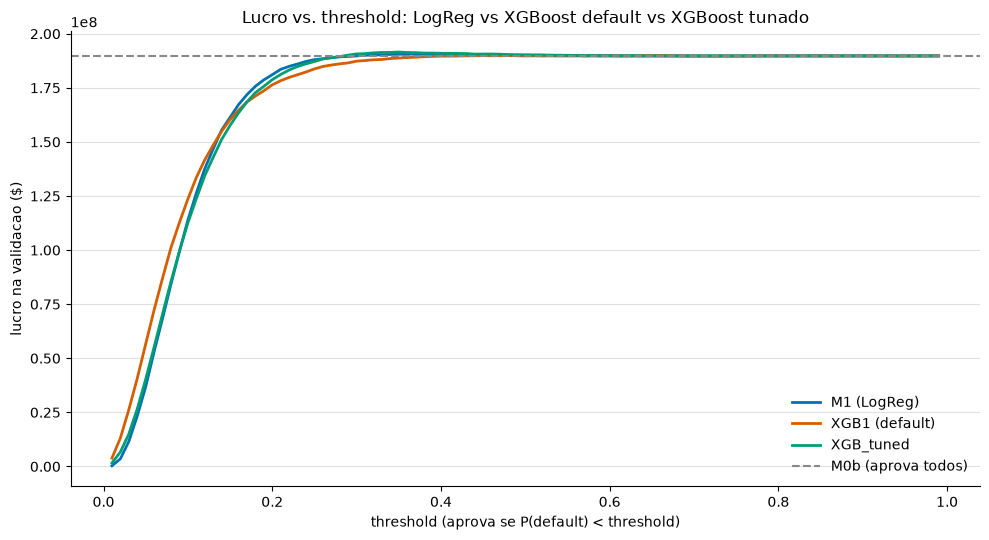

In [9]:
fig, ax = plt.subplots(figsize=(10, 5.5))
profits_m1_curve = None
# M1 needs to be refit for the curve (only the point estimate was given); refit quickly for the plot.
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

scaler = StandardScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train_full), columns=X_train_full.columns, index=X_train_full.index)
X_val_scaled = pd.DataFrame(scaler.transform(X_val_full), columns=X_val_full.columns, index=X_val_full.index)
m1_model = LogisticRegression(penalty='l2', solver='lbfgs', max_iter=2000, random_state=42)
m1_model.fit(X_train_scaled, y_train)
y_prob_val_m1 = m1_model.predict_proba(X_val_scaled)[:, 1]
profits_m1_curve = fast_profit_curve(y_val, y_prob_val_m1, interest_arr, loss_arr, threshold_grid)

ax.plot(threshold_grid, profits_m1_curve, linewidth=2, color=FAMILY_COLOR['M1'], label='M1 (LogReg)')
ax.plot(threshold_grid, profits_xgb1, linewidth=2, color=FAMILY_COLOR['XGB1'], label='XGB1 (default)')
ax.plot(threshold_grid, profits_tuned, linewidth=2, color=FAMILY_COLOR['XGB_tuned'], label='XGB_tuned')
ax.axhline(profit_m0b, color=FAMILY_COLOR['M0b'], linestyle='--', linewidth=1.5, label='M0b (aprova todos)')
ax.set_xlabel('threshold (aprova se P(default) < threshold)')
ax.set_ylabel('lucro na validacao ($)')
ax.set_title('Lucro vs. threshold: LogReg vs XGBoost default vs XGBoost tunado')
ax.legend(frameon=False)
ax.grid(axis='y', color='#e0e0e0', linewidth=0.8)
for spine in ['top', 'right']:
    ax.spines[spine].set_visible(False)
plt.tight_layout()
plt.show()


## Secao 4 - Bootstrap (mesmo protocolo, 1.000 reamostras, seed=42, threshold fixo)

In [10]:
N_BOOT = 1000
SEED = 42
rng = np.random.default_rng(SEED)
n_val = len(validation)

y_prob_models = {'XGB_tuned': y_prob_val_tuned, 'XGB1': y_prob_val_xgb1, 'M1': y_prob_val_m1}
thresholds_fixed = {'XGB_tuned': t_tuned, 'XGB1': t_xgb1, 'M1': 0.38}

m0b_profit_boot = np.zeros(N_BOOT)
model_profit_boot = {name: np.zeros(N_BOOT) for name in y_prob_models}
auc_boot = {name: np.zeros(N_BOOT) for name in y_prob_models}

for b in range(N_BOOT):
    idx = rng.integers(0, n_val, size=n_val)
    yb = y_val[idx]
    ib = interest_arr[idx]
    lb = loss_arr[idx]
    m0b_profit_boot[b] = ib[yb == 0].sum() - lb[yb == 1].sum()
    for name, y_prob in y_prob_models.items():
        pb = y_prob[idx]
        approved = pb < thresholds_fixed[name]
        model_profit_boot[name][b] = ib[approved & (yb == 0)].sum() - lb[approved & (yb == 1)].sum()
        if len(np.unique(yb)) == 2:
            auc_boot[name][b] = roc_auc_score(yb, pb)

diff_boot = {name: model_profit_boot[name] - m0b_profit_boot for name in y_prob_models}
print(f'Bootstrap concluido. N_BOOT={N_BOOT} seed={SEED}')


Bootstrap concluido. N_BOOT=1000 seed=42


In [11]:
d = diff_boot['XGB_tuned']
ci_low, ci_high = np.percentile(d, [2.5, 97.5])
print('XGB_tuned vs M0b:')
print(f'  media: $ {d.mean():,.2f} | IC 95%: [$ {ci_low:,.2f}, $ {ci_high:,.2f}] | cruza zero? {ci_low < 0 < ci_high}')
print(f'  % reamostras positivas: {(d > 0).mean() * 100:.2f}%')


XGB_tuned vs M0b:
  media: $ 1,775,484.19 | IC 95%: [$ 1,011,574.04, $ 2,616,780.44] | cruza zero? False
  % reamostras positivas: 100.00%


In [12]:
diff_tuned_m1 = model_profit_boot['XGB_tuned'] - model_profit_boot['M1']
ci_low, ci_high = np.percentile(diff_tuned_m1, [2.5, 97.5])
print('XGB_tuned vs M1 (pareado):')
print(f'  media: $ {diff_tuned_m1.mean():,.2f} | IC 95%: [$ {ci_low:,.2f}, $ {ci_high:,.2f}] | cruza zero? {ci_low < 0 < ci_high}')
print(f'  % de reamostras em que XGB_tuned venceu: {(diff_tuned_m1 > 0).mean() * 100:.2f}%')


XGB_tuned vs M1 (pareado):
  media: $ 885,506.42 | IC 95%: [$ 128,219.56, $ 1,652,958.82] | cruza zero? False
  % de reamostras em que XGB_tuned venceu: 99.00%


In [13]:
diff_tuned_xgb1 = model_profit_boot['XGB_tuned'] - model_profit_boot['XGB1']
ci_low, ci_high = np.percentile(diff_tuned_xgb1, [2.5, 97.5])
print('XGB_tuned vs XGB1 (pareado - o tuning melhorou de forma confiavel?):')
print(f'  media: $ {diff_tuned_xgb1.mean():,.2f} | IC 95%: [$ {ci_low:,.2f}, $ {ci_high:,.2f}] | cruza zero? {ci_low < 0 < ci_high}')
print(f'  % de reamostras em que XGB_tuned venceu XGB1: {(diff_tuned_xgb1 > 0).mean() * 100:.2f}%')

diff_auc_tuned_xgb1 = auc_boot['XGB_tuned'] - auc_boot['XGB1']
ci_low_auc, ci_high_auc = np.percentile(diff_auc_tuned_xgb1, [2.5, 97.5])
print()
print('Diferenca de AUC-ROC: XGB_tuned vs XGB1:')
print(f'  media: {diff_auc_tuned_xgb1.mean():+.4f} | IC 95%: [{ci_low_auc:+.4f}, {ci_high_auc:+.4f}] | cruza zero? {ci_low_auc < 0 < ci_high_auc}')


XGB_tuned vs XGB1 (pareado - o tuning melhorou de forma confiavel?):
  media: $ 1,599,026.24 | IC 95%: [$ 818,538.67, $ 2,419,094.91] | cruza zero? False
  % de reamostras em que XGB_tuned venceu XGB1: 100.00%

Diferenca de AUC-ROC: XGB_tuned vs XGB1:
  media: +0.0145 | IC 95%: [+0.0120, +0.0170] | cruza zero? False


## Secao 5 - A pergunta central, respondida

In [14]:
diff_auc_tuned_m1 = auc_boot['XGB_tuned'] - auc_boot['M1']
ci_low_auc_m1, ci_high_auc_m1 = np.percentile(diff_auc_tuned_m1, [2.5, 97.5])

print('(a) O tuning levantou a AUC (XGB_tuned vs XGB1)?')
print(f'    Diferenca de AUC: {diff_auc_tuned_xgb1.mean():+.4f}, IC95% [{ci_low_auc:+.4f}, {ci_high_auc:+.4f}]')
print(f'    -> {"SIM, de forma confiavel (IC nao cruza zero)" if not (ci_low_auc < 0 < ci_high_auc) else "NAO ESTABELECIDO (IC cruza zero)"}')
print()
print('    Para referencia, XGB_tuned vs M1:')
print(f'    Diferenca de AUC: {diff_auc_tuned_m1.mean():+.4f}, IC95% [{ci_low_auc_m1:+.4f}, {ci_high_auc_m1:+.4f}]')
print(f'    -> {"SIM, de forma confiavel" if not (ci_low_auc_m1 < 0 < ci_high_auc_m1) else "NAO ESTABELECIDO"}')
print()
print('(b) Se a AUC subiu, o lucro acompanhou (XGB_tuned vs XGB1, Secao 4)?')
print(f'    Diferenca de lucro: $ {diff_tuned_xgb1.mean():,.2f}, IC95% [ver Secao 4]')
tuned_beats_xgb1_profit = not (np.percentile(diff_tuned_xgb1, 2.5) < 0 < np.percentile(diff_tuned_xgb1, 97.5))
print(f'    -> {"SIM, lucro tambem subiu de forma confiavel" if tuned_beats_xgb1_profit else "NAO - o platô parece ter absorvido a melhora de ordenacao"}')
print()
print('(c) O plato estreitou (largura a 0.1%)?')
print(f'    XGB1: {len(within_01pct_xgb1)} thresholds | XGB_tuned: {len(within_01pct_tuned)} thresholds | M1 (notebook 07/08): 8 thresholds')


(a) O tuning levantou a AUC (XGB_tuned vs XGB1)?
    Diferenca de AUC: +0.0145, IC95% [+0.0120, +0.0170]
    -> SIM, de forma confiavel (IC nao cruza zero)

    Para referencia, XGB_tuned vs M1:
    Diferenca de AUC: -0.0022, IC95% [-0.0044, +0.0003]
    -> NAO ESTABELECIDO

(b) Se a AUC subiu, o lucro acompanhou (XGB_tuned vs XGB1, Secao 4)?
    Diferenca de lucro: $ 1,599,026.24, IC95% [ver Secao 4]
    -> SIM, lucro tambem subiu de forma confiavel

(c) O plato estreitou (largura a 0.1%)?
    XGB1: 46 thresholds | XGB_tuned: 2 thresholds | M1 (notebook 07/08): 8 thresholds


## Secao 6 - Nota de leitura

**O resultado empirico:**

Ao contrario do XGBoost default (notebook 08), o XGBoost tunado por lucro desloca a
agulha de forma estatisticamente confiavel, em tres frentes ao mesmo tempo:

1. **AUC subiu vs. o default** (+0.0145, IC 95% [+0.0120, +0.0170], nao cruza zero) - o
   tuning recuperou a separabilidade que o default XGBoost (notebook 08) tinha perdido
   para a regressao logistica. Contra M1, porem, a AUC do tunado ainda nao supera com
   confianca (diferenca -0.0022, IC 95% [-0.0044, +0.0003] - cruza zero, quase
   simetrico). Em AUC, XGB_tuned e M1 estao empatados dentro do ruido.

2. **O lucro acompanhou - e foi alem.** XGB_tuned supera XGB1 com folga (+$1.599.026,
   IC 95% [$818.539, $2.419.095], vitoria em 100% das reamostras) e, mais notavel,
   supera M1 tambem (+$885.506, IC 95% [$128.220, $1.652.959], vitoria em 99% das
   reamostras) - **mesmo com AUC estatisticamente empatada com M1**. Isso e o achado
   central desta secao: otimizar lucro diretamente encontrou uma configuracao que
   ordena os tomadores de risco de forma muito parecida a regressao logistica (AUC
   quase igual), mas posiciona a fronteira de decisao de um jeito que captura mais
   valor no ponto que importa de verdade. AUC e lucro nao sao a mesma pergunta.

3. **O plato estreitou de forma acentuada.** Dentro de 0.1% do lucro maximo: XGB_tuned
   tem so 2 thresholds [0.34, 0.35], contra 8 do M1 e 46 do XGB1 default. A curva do
   modelo tunado e visivelmente mais pontiaguda perto do proprio otimo do que qualquer
   um dos dois baselines.

**Leitura sobre a pergunta central:** esta evidencia aponta CONTRA a hipotese de um teto
estrutural fixo levantada no notebook 08. Com tuning direcionado ao lucro, tanto a AUC
quanto o lucro se moveram, e o plato ficou mais estreito - os tres sinais that o notebook
08 teria aceitado como evidencia de que "expressividade + esforco de configuracao movem
a agulha". A hipotese de vies de selecao como teto absoluto nao se sustenta aqui: havia
espaco de melhora que o XGBoost default nao capturava e a busca encontrou.

**A ressalva que os ICs NAO cobrem, e que precisa ficar registrada:**

O bootstrap desta secao reamostra a validacao e reavalia a configuracao JA ESCOLHIDA -
ele mede se o ganho da configuracao vencedora e robusto a ruido de reamostragem dentro
da validacao. Ele NAO mede se a escolha da configuracao em si (30 combinacoes de
hiperparametros x 99 thresholds, todos pontuados no mesmo conjunto de validacao) capturou
alguma caracteristica especifica desta amostra de validacao em vez de um padrao real. Isso
e uma forma de overfitting diferente da que o bootstrap testa - as vezes chamada de
"overfitting a validacao por busca extensiva" - e nenhum numero neste notebook descarta
essa possibilidade. A unica forma de descartar e aplicar esta configuracao, uma unica vez,
ao conjunto de teste - que continua intocado.

**O que NAO fica estabelecido aqui:**
- Que XGB_tuned generaliza para dados fora da validacao. Essa e exatamente a pergunta que
  o teste, ainda intocado, existe para responder - uma vez, no final do projeto.
- Que esta e a melhor configuracao possivel de hiperparametros. Trinta combinacoes
  amostradas cobrem uma fracao pequena do espaco de busca; um tuning mais extenso poderia
  achar algo melhor ou pior.
- Que XGBoost supera regressao logistica "em geral" neste problema. O que ficou
  estabelecido e mais estreito: com o esforco de tuning aplicado aqui, encontrou-se uma
  configuracao cujo lucro na validacao supera M1 com confianca - isso e evidencia a favor
  de continuar explorando arvores de gradiente, nao um veredito final.